In [37]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [38]:
# defining state

class BMIstate(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [39]:
def CalculateBMI(state : BMIstate) -> BMIstate:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

def LabelBMI(state : BMIstate) -> BMIstate:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "overweight"
    else:
        state["category"] = "Obese"
    return state


In [40]:
# define the graph

graph = StateGraph(BMIstate)

#adding nodes to graph
graph.add_node('calculate_bmi', CalculateBMI)
graph.add_node('Label_Bmi', LabelBMI)

#adding edges to the graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi', 'Label_Bmi')
graph.add_edge('Label_Bmi', END)

#compile and execute graph
workflow = graph.compile()
final_state = workflow.invoke({'weight_kg':40,'height_m':1.73})
print(final_state)

{'weight_kg': 40, 'height_m': 1.73, 'bmi': 13.36, 'category': 'Underweight'}


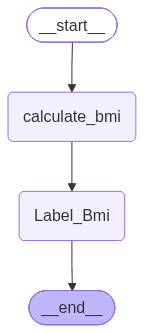

In [41]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())